# MJD Transformer Results: Energy-Aware Classification

This notebook never trains a model. It loads completed run artifacts and, once per classification run, restores the saved best checkpoint for held-out-test inference so EnergyBench can measure energy-matched AUC and energy independence. Generated metrics are cached under each run's `energybench_classification/` directory.

In [2]:
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch

configured_root = os.environ.get('MJD_TRANSFORMER_PROJECT_ROOT')
candidate_roots = []
if configured_root:
    candidate_roots.append(Path(configured_root).expanduser())
candidate_roots.extend([
    Path.cwd() / 'mjd_detector',
    Path.cwd(),
    Path.cwd().parent / 'mjd_detector',
    Path.cwd().parent,
    Path.cwd().parent.parent / 'mjd_detector',
])
PROJECT_ROOT = next(
    (candidate.resolve() for candidate in candidate_roots
     if (candidate / 'mjd_transformer').is_dir()
     and (candidate / 'mjdbench').is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'Could not locate mjd_detector; set MJD_TRANSFORMER_PROJECT_ROOT.'
    )
WORKFLOW_ROOT = PROJECT_ROOT.parent / 'evalutaions_workflow'
for path in (PROJECT_ROOT, WORKFLOW_ROOT):
    value = str(path)
    if value not in sys.path:
        sys.path.insert(0, value)

from mjdbench import DataConfig, TrainingConfig, prepare_dataset
from mjd_transformer.energy_aware import evaluate_run

DATA_ROOT = Path(os.environ.get(
    'MJD_BENCH_DATA', str(PROJECT_ROOT.parent / 'data' / 'MJD')
)).expanduser()
OUTPUT_ROOT = Path(os.environ.get(
    'MJD_OUTPUT_ROOT',
    str(PROJECT_ROOT / 'results' / 'transformer_official_v1'),
)).expanduser()
SUMMARY_PATH = OUTPUT_ROOT / 'transformer_results.csv'

# True: evaluate runs without cached energy-aware metrics. Existing artifacts
# are skipped, so rerunning this notebook is cheap after the first pass.
RUN_ENERGY_AWARE_EVALUATION = True
RECOMPUTE_ENERGY_AWARE_EVALUATION = False

print('Dataset:', DATA_ROOT)
print('Results:', OUTPUT_ROOT)
print('CUDA available:', torch.cuda.is_available())

Dataset: /home/klz/Data/zeronu_benchmark/Transformer_Approach/data/MJD
Results: /home/klz/Data/zeronu_benchmark/Transformer_Approach/mjd_detector/results/transformer_official_v1
CUDA available: True


In [3]:
def load_completed_runs(output_root):
    rows = []
    for run_dir in sorted(output_root.iterdir() if output_root.is_dir() else []):
        path = run_dir / 'run_summary.json'
        if path.is_file():
            rows.append(json.loads(path.read_text(encoding='utf-8')))
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(
        ['task', 'tokenization', 'position_encoding']
    ).reset_index(drop=True)

results = load_completed_runs(OUTPUT_ROOT)
if results.empty and SUMMARY_PATH.is_file():
    results = pd.read_csv(SUMMARY_PATH)
print(f'Completed runs: {len(results)}/12')
display(results)
from pathlib import Path

DATA_ROOT = Path(
    "/home/klz/Data/zeronu_benchmark/MJD"
)

print(DATA_ROOT)
print(DATA_ROOT.is_dir())

Completed runs: 12/12


,run_id,task,tokenization,position_encoding,parameter_count,train_events,validation_events,test_events,epochs_completed,best_epoch,best_validation_score,training_seconds,minutes_per_epoch,evaluation_seconds,test_auc,test_accuracy,test_mae_kev,test_rmse_kev,test_bias_kev,test_loss
0,classification__pulse_entities__coordinate_mlp,classification,pulse_entities,coordinate_mlp,111105,936000,104000,390000,32,27,0.932519,39806.352543,20.732475,355.447236,0.933425,0.856590,NaN,NaN,NaN,0.306631
1,classification__pulse_entities__fourier_coordi...,classification,pulse_entities,fourier_coordinates,113409,936000,104000,390000,28,23,0.944066,35291.336628,21.006748,441.302560,0.944452,0.868518,NaN,NaN,NaN,0.282995
2,classification__raw_patches__coordinate_mlp,classification,raw_patches,coordinate_mlp,112257,936000,104000,390000,50,46,0.973894,16938.540261,5.646180,76.478796,0.974491,0.916733,NaN,NaN,NaN,0.197765
3,classification__raw_patches__fourier_coordinates,classification,raw_patches,fourier_coordinates,114561,936000,104000,390000,49,44,0.981123,15698.111831,5.339494,76.703532,0.981495,0.927854,NaN,NaN,NaN,0.176425
4,classification__segment_summary__coordinate_mlp,classification,segment_summary,coordinate_mlp,111105,936000,104000,390000,36,31,0.966501,18932.468532,8.765032,118.902973,0.967016,0.904849,NaN,NaN,NaN,0.221151
5,classification__segment_summary__fourier_coord...,classification,segment_summary,fourier_coordinates,113409,936000,104000,390000,28,23,0.970253,33275.812712,19.807031,299.004448,0.970892,0.912754,NaN,NaN,NaN,0.203295
6,regression__pulse_entities__coordinate_mlp,regression,pulse_entities,coordinate_mlp,111105,355796,39533,148251,21,16,53.836124,11798.536693,9.363918,155.670483,NaN,NaN,15.038597,53.307583,4.714835,2841.043533
7,regression__pulse_entities__fourier_coordinates,regression,pulse_entities,fourier_coordinates,113409,355796,39533,148251,13,8,47.623348,7280.014150,9.333351,158.227824,NaN,NaN,18.623940,44.363903,-7.158234,1967.801535
8,regression__raw_patches__coordinate_mlp,regression,raw_patches,coordinate_mlp,112257,355796,39533,148251,15,10,21.900526,5293.493804,5.881660,105.889745,NaN,NaN,9.673210,24.197121,-1.485877,585.408059
9,regression__raw_patches__fourier_coordinates,regression,raw_patches,fourier_coordinates,114561,355796,39533,148251,28,23,21.043751,9886.110560,5.884590,106.082169,NaN,NaN,9.995461,22.221966,5.594021,493.723317


/home/klz/Data/zeronu_benchmark/MJD
True


## Compute missing energy-aware classification metrics

The original classification prediction files omitted energy. This cell performs evaluation-only inference over the same 390,000-event held-out test set. MJD energies are stored in keV and are converted to MeV only at the EnergyBench boundary. The evaluator uses zero-anchored 5 keV bins extending through the observed MJD test range, matching the older MJD EnergyBench convention.

In [4]:
classification_rows = (
    results.loc[results['task'] == 'classification'].copy()
    if not results.empty else pd.DataFrame()
)
pending = []
for row in classification_rows.itertuples(index=False):
    metrics_path = (
        OUTPUT_ROOT / row.run_id / 'energybench_classification' / 'metrics.json'
    )
    if RECOMPUTE_ENERGY_AWARE_EVALUATION or not metrics_path.is_file():
        pending.append(row)

if RUN_ENERGY_AWARE_EVALUATION and pending:
    data_config = DataConfig(
        data_root=DATA_ROOT,
        validation_fraction=0.10,
        baseline_samples=200,
        classification_amplitude_normalization=True,
        regression_waveform_scale=1.0,
        seed=42,
    )
    training_config = TrainingConfig()
    classification_data = prepare_dataset(
        task='classification',
        data_config=data_config,
        batch_size=training_config.batch_size,
        num_workers=training_config.num_workers,
        limit_per_split=None,
    )
    print('Pending classification runs:', len(pending))
    print('Held-out test events:', classification_data.counts['test'])
    for row in pending:
        print('\nEvaluating:', row.run_id)
        metrics = evaluate_run(
            OUTPUT_ROOT / row.run_id,
            classification_data.test_loader,
            expected_auc=float(row.test_auc),
            device='auto',
            overwrite=RECOMPUTE_ENERGY_AWARE_EVALUATION,
        )
        print({
            'test_auc': metrics.get('auc'),
            'energy_matched_auc': metrics.get('matched_auc'),
            'energy_independence_score': metrics.get(
                'energy_independence_score'
            ),
            'evaluation_seconds': metrics.get('evaluation_seconds'),
        })
elif not pending:
    print('All six classification runs already have energy-aware metrics.')
else:
    print('Evaluation disabled; displaying existing artifacts only.')

All six classification runs already have energy-aware metrics.


In [ ]:
def load_energy_metrics(run_id):
    path = OUTPUT_ROOT / run_id / 'energybench_classification' / 'metrics.json'
    return json.loads(path.read_text()) if path.is_file() else {}

analysis_results = load_completed_runs(OUTPUT_ROOT)
if analysis_results.empty and SUMMARY_PATH.is_file():
    analysis_results = pd.read_csv(SUMMARY_PATH)
classification = analysis_results.loc[
    analysis_results['task'] == 'classification'
].copy()

energy_rows = []
for run_id in classification.get('run_id', []):
    metrics = load_energy_metrics(run_id)
    energy_rows.append({
        'run_id': run_id,
        'energy_matched_auc': metrics.get('matched_auc'),
        'energy_independence_score': metrics.get('energy_independence_score'),
        'worst_energy_independence_score': metrics.get(
            'worst_energy_independence_score'
        ),
        'shortcut_gap': metrics.get('shortcut_gap'),
        'matched_auc_status': metrics.get('matched_auc_status'),
    })
if energy_rows:
    classification = classification.merge(
        pd.DataFrame(energy_rows), on='run_id', how='left'
    )
classification = classification.rename(columns={
    'best_validation_score': 'validation_auc',
})
classification = classification.sort_values('test_auc', ascending=False)

classification_columns = [
    'tokenization', 'position_encoding',
    'validation_auc', 'test_auc', 'energy_matched_auc',
    'energy_independence_score', 'epochs_completed', 'minutes_per_epoch',
    'best_epoch', 'test_accuracy', 'worst_energy_independence_score',
    'shortcut_gap', 'matched_auc_status',
]
print('Classification — higher AUC and independence are better')
display(classification[classification_columns])

#classification.to_csv("transformer_final_results.csv")

Classification — higher AUC and independence are better


,tokenization,position_encoding,validation_auc,test_auc,energy_matched_auc,energy_independence_score,epochs_completed,minutes_per_epoch,best_epoch,test_accuracy,worst_energy_independence_score,shortcut_gap,matched_auc_status
3,raw_patches,fourier_coordinates,0.981123,0.981495,0.981047,0.787611,49,5.339494,44,0.927854,0.786882,0.000749,ok
2,raw_patches,coordinate_mlp,0.973894,0.974491,0.973451,0.798282,50,5.646180,46,0.916733,0.793519,0.001242,ok
5,segment_summary,fourier_coordinates,0.970253,0.970892,0.969138,0.781776,28,19.807031,23,0.912754,0.775846,0.001898,ok
4,segment_summary,coordinate_mlp,0.966501,0.967016,0.965394,0.798970,36,8.765032,31,0.904849,0.797188,0.001751,ok
1,pulse_entities,fourier_coordinates,0.944066,0.944452,0.941388,0.802062,28,21.006748,23,0.868518,0.791295,0.002943,ok
0,pulse_entities,coordinate_mlp,0.932519,0.933425,0.929397,0.811568,32,20.732475,27,0.856590,0.794897,0.003770,ok


In [6]:
regression = analysis_results.loc[
    analysis_results['task'] == 'regression'
].copy()
if not regression.empty:
    regression = regression.sort_values('test_rmse_kev', ascending=True)
    print('Regression — lower RMSE is better')
    display(regression[[
        'tokenization', 'position_encoding', 'test_rmse_kev',
        'test_mae_kev', 'test_bias_kev', 'epochs_completed',
        'minutes_per_epoch', 'best_epoch', 'parameter_count', 'test_events',
    ]])

Regression — lower RMSE is better


,tokenization,position_encoding,test_rmse_kev,test_mae_kev,test_bias_kev,epochs_completed,minutes_per_epoch,best_epoch,parameter_count,test_events
9,raw_patches,fourier_coordinates,22.221966,9.995461,5.594021,28,5.884590,23,114561,148251
8,raw_patches,coordinate_mlp,24.197121,9.673210,-1.485877,15,5.881660,10,112257,148251
11,segment_summary,fourier_coordinates,24.584166,9.558511,3.059135,13,8.353915,8,113409,148251
10,segment_summary,coordinate_mlp,34.390846,14.663388,8.356632,27,8.366833,22,111105,148251
7,pulse_entities,fourier_coordinates,44.363903,18.623940,-7.158234,13,9.333351,8,113409,148251
6,pulse_entities,coordinate_mlp,53.307583,15.038597,4.714835,21,9.363918,16,111105,148251


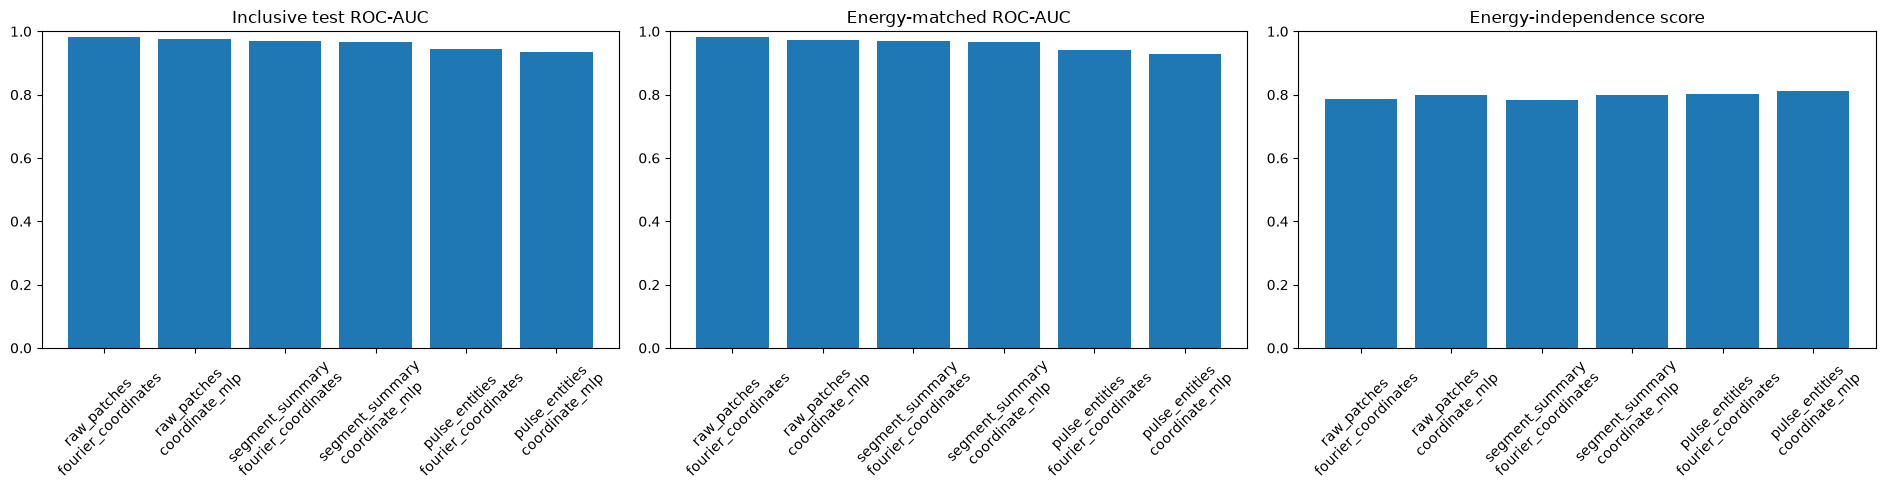

In [7]:
if not classification.empty:
    plot_table = classification.copy()
    plot_table['representation'] = (
        plot_table['tokenization'] + '\n' + plot_table['position_encoding']
    )
    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    values = [
        ('test_auc', 'Inclusive test ROC-AUC'),
        ('energy_matched_auc', 'Energy-matched ROC-AUC'),
        ('energy_independence_score', 'Energy-independence score'),
    ]
    for axis, (column, title) in zip(axes, values):
        axis.bar(plot_table['representation'], plot_table[column])
        axis.set_title(title)
        axis.set_ylim(0.0, 1.0)
        axis.tick_params(axis='x', rotation=45)
    fig.tight_layout()
    plt.show()

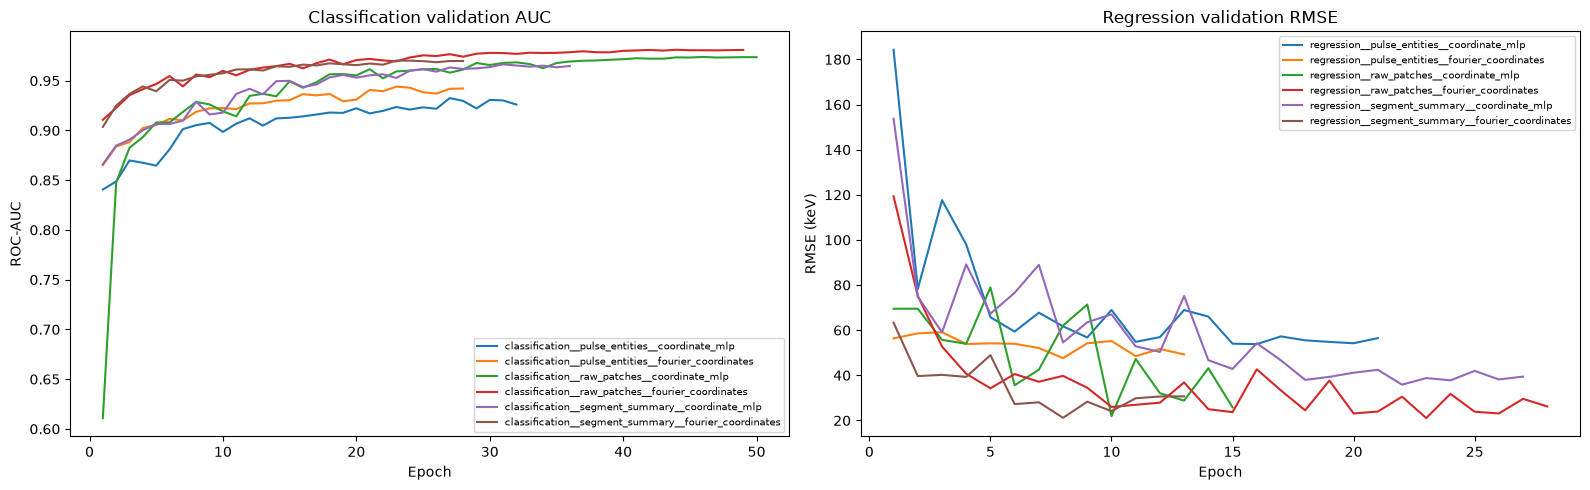

In [8]:
history_rows = []
for run_dir in sorted(OUTPUT_ROOT.iterdir() if OUTPUT_ROOT.is_dir() else []):
    history_path = run_dir / 'history.json'
    config_path = run_dir / 'run_config.json'
    if not history_path.is_file() or not config_path.is_file():
        continue
    history = json.loads(history_path.read_text())
    config = json.loads(config_path.read_text())
    for epoch in history:
        metrics = epoch['validation_metrics']
        history_rows.append({
            'run_id': config['run_id'],
            'task': config['task'],
            'epoch': epoch['epoch'],
            'validation_auc': metrics.get('macro_auc'),
            'validation_rmse_kev': metrics.get('rmse_kev'),
        })
history_table = pd.DataFrame(history_rows)
if not history_table.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    class_history = history_table.loc[history_table['task'] == 'classification']
    reg_history = history_table.loc[history_table['task'] == 'regression']
    for run_id, group in class_history.groupby('run_id'):
        axes[0].plot(group['epoch'], group['validation_auc'], label=run_id)
    axes[0].set(title='Classification validation AUC', xlabel='Epoch', ylabel='ROC-AUC')
    if not class_history.empty:
        axes[0].legend(fontsize=7)
    for run_id, group in reg_history.groupby('run_id'):
        axes[1].plot(group['epoch'], group['validation_rmse_kev'], label=run_id)
    axes[1].set(title='Regression validation RMSE', xlabel='Epoch', ylabel='RMSE (keV)')
    if not reg_history.empty:
        axes[1].legend(fontsize=7)
    fig.tight_layout()
    plt.show()

In [10]:
classification

,run_id,task,tokenization,position_encoding,parameter_count,train_events,validation_events,test_events,epochs_completed,best_epoch,...,test_accuracy,test_mae_kev,test_rmse_kev,test_bias_kev,test_loss,energy_matched_auc,energy_independence_score,worst_energy_independence_score,shortcut_gap,matched_auc_status
3,classification__raw_patches__fourier_coordinates,classification,raw_patches,fourier_coordinates,114561,936000,104000,390000,49,44,...,0.927854,NaN,NaN,NaN,0.176425,0.981047,0.787611,0.786882,0.000749,ok
2,classification__raw_patches__coordinate_mlp,classification,raw_patches,coordinate_mlp,112257,936000,104000,390000,50,46,...,0.916733,NaN,NaN,NaN,0.197765,0.973451,0.798282,0.793519,0.001242,ok
5,classification__segment_summary__fourier_coord...,classification,segment_summary,fourier_coordinates,113409,936000,104000,390000,28,23,...,0.912754,NaN,NaN,NaN,0.203295,0.969138,0.781776,0.775846,0.001898,ok
4,classification__segment_summary__coordinate_mlp,classification,segment_summary,coordinate_mlp,111105,936000,104000,390000,36,31,...,0.904849,NaN,NaN,NaN,0.221151,0.965394,0.798970,0.797188,0.001751,ok
1,classification__pulse_entities__fourier_coordi...,classification,pulse_entities,fourier_coordinates,113409,936000,104000,390000,28,23,...,0.868518,NaN,NaN,NaN,0.282995,0.941388,0.802062,0.791295,0.002943,ok
0,classification__pulse_entities__coordinate_mlp,classification,pulse_entities,coordinate_mlp,111105,936000,104000,390000,32,27,...,0.856590,NaN,NaN,NaN,0.306631,0.929397,0.811568,0.794897,0.003770,ok


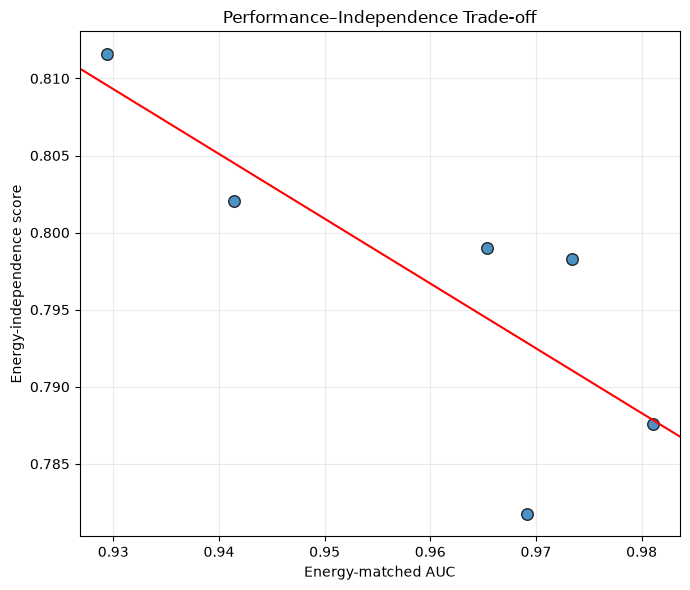

                                OLS Regression Results                               
Dep. Variable:     energy_independence_score   R-squared:                       0.634
Model:                                   OLS   Adj. R-squared:                  0.543
Method:                        Least Squares   F-statistic:                     6.933
Date:                       Mon, 14 Sep 2026   Prob (F-statistic):             0.0580
Time:                               15:10:30   Log-Likelihood:                 22.326
No. Observations:                          6   AIC:                            -40.65
Df Residuals:                              4   BIC:                            -41.07
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

/home/liuser/miniconda3/envs/zeronu-next/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:3158: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  omni, omnipv = cached("omni_normtest", lambda: omni_normtest(self.wresid))


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.graphics.regressionplots import abline_plot


x = "energy_matched_auc"
y = "energy_independence_score"

plot_data = classification[
    [x, y]
].dropna()

regression = smf.ols(
    formula=f"{y} ~ {x}",
    data=plot_data,
).fit()

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.scatter(
    plot_data[x],
    plot_data[y],
    s=70,
    alpha=0.8,
    edgecolor="black",
)

abline_plot(
    model_results=regression,
    ax=ax,
    color="red",
)

ax.set_xlabel("Energy-matched AUC")
ax.set_ylabel("Energy-independence score")
ax.set_title("Performance–Independence Trade-off")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(regression.summary())